# LightGBM Global RM/PM Model

This is a global tabular model over RM/PM demand history. It is not an M5 transfer claim and not a finished production claim by itself.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import Image, Markdown, display
except Exception:
    def display(value):
        print(value)
    def Markdown(text):
        return text
    class Image:
        def __init__(self, filename=None, **kwargs):
            self.filename = filename
        def __repr__(self):
            return f"Image(filename={self.filename!r})"

ROOT = Path.cwd()
if ROOT.name != "v7_rm_pm_forecast_planning":
    ROOT = Path("Ai miroservices/modeling/v7_rm_pm_forecast_planning").resolve()
OUT = ROOT / "outputs"
PLOTS = OUT / "plots"
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)

def load_csv(name, **kwargs):
    path = OUT / name
    if not path.exists():
        raise FileNotFoundError(f"Missing artifact: {path}. Run PYTHONPATH=. python3 -m pipeline.run_all first.")
    return pd.read_csv(path, **kwargs)

def load_json(name):
    path = OUT / name
    if not path.exists():
        raise FileNotFoundError(f"Missing artifact: {path}. Run PYTHONPATH=. python3 -m pipeline.run_all first.")
    return json.loads(path.read_text())

def show_plot(name):
    path = PLOTS / name
    if path.exists():
        display(Image(filename=str(path)))
    else:
        display(Markdown(f"Plot not generated: `{path}`"))

In [2]:
lgb_eval = load_csv('lightgbm_evaluation.csv')
lgb_eval

,model,rows,materials,WAPE,MAE,RMSE,Bias,under_forecast_rate
0,lightgbm_global_rm_pm,1728,288,0.250892,433.242183,2421.593928,0.015784,0.506366


In [3]:
importance = load_csv('model_feature_importance.csv')
importance.head(30)

,feature,importance_gain,importance_split,importance_gain_share
0,roll_mean_12,577811.837696,1024,0.867281
1,roll_mean_6,53761.912021,554,0.080695
2,roll_mean_3,12023.589659,522,0.018047
3,roll_std_12,4195.519998,697,0.006297
4,roll_std_6,3638.141481,677,0.005461
5,lag_6,2760.744057,661,0.004144
6,lag_1,2545.768309,622,0.003821
7,lag_3,1814.384395,640,0.002723
8,lag_2,1672.533594,620,0.002510
9,roll_std_3,1637.373807,668,0.002458


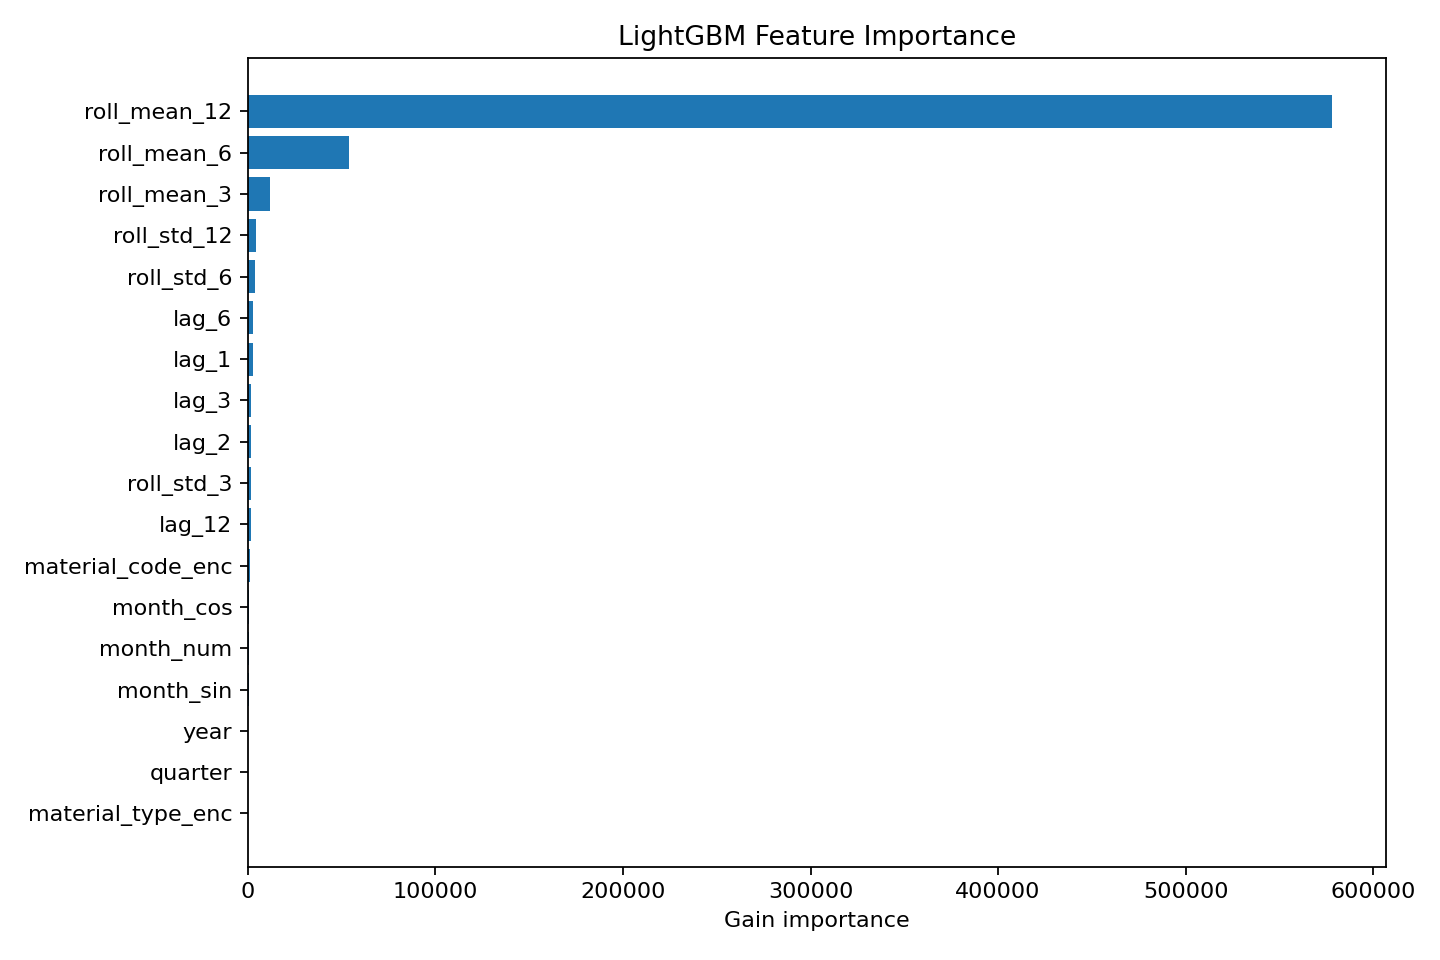

In [4]:
show_plot('lightgbm_feature_importance.png')

In [5]:
rows = load_csv("lightgbm_backtest_rows.csv", parse_dates=["month"])
rows.head(30)

,material_id,material_code,description,material_type,month,actual,model,prediction,abs_error,error
0,00c543ff-b1f0-4938-a6ac-e490ea98b94d,100012,AMPHISOL,raw_material,2025-07-01,150.0,lightgbm_global_rm_pm,104.133322,45.866678,-45.866678
1,00c543ff-b1f0-4938-a6ac-e490ea98b94d,100012,AMPHISOL,raw_material,2025-08-01,103.0,lightgbm_global_rm_pm,106.167760,3.167760,3.167760
2,00c543ff-b1f0-4938-a6ac-e490ea98b94d,100012,AMPHISOL,raw_material,2025-09-01,196.0,lightgbm_global_rm_pm,56.617960,139.382040,-139.382040
3,00c543ff-b1f0-4938-a6ac-e490ea98b94d,100012,AMPHISOL,raw_material,2025-10-01,117.0,lightgbm_global_rm_pm,79.368471,37.631529,-37.631529
4,00c543ff-b1f0-4938-a6ac-e490ea98b94d,100012,AMPHISOL,raw_material,2025-11-01,112.0,lightgbm_global_rm_pm,105.403201,6.596799,-6.596799
5,00c543ff-b1f0-4938-a6ac-e490ea98b94d,100012,AMPHISOL,raw_material,2025-12-01,112.0,lightgbm_global_rm_pm,106.049047,5.950953,-5.950953
6,0af15859-8d15-4b62-9ead-68e73db224d8,101208,SHEBU - WS,raw_material,2025-07-01,0.0,lightgbm_global_rm_pm,0.019292,0.019292,0.019292
7,0af15859-8d15-4b62-9ead-68e73db224d8,101208,SHEBU - WS,raw_material,2025-08-01,0.0,lightgbm_global_rm_pm,0.036983,0.036983,0.036983
8,0af15859-8d15-4b62-9ead-68e73db224d8,101208,SHEBU - WS,raw_material,2025-09-01,0.0,lightgbm_global_rm_pm,0.037729,0.037729,0.037729
9,0af15859-8d15-4b62-9ead-68e73db224d8,101208,SHEBU - WS,raw_material,2025-10-01,0.0,lightgbm_global_rm_pm,0.036616,0.036616,0.036616


In [6]:
rows.groupby("material_type").agg(
    rows=("actual", "size"),
    materials=("material_id", "nunique"),
    actual=("actual", "sum"),
    prediction=("prediction", "sum"),
)

,rows,materials,actual,prediction
material_type,,,,
raw_material,1728,288,2983921.0,3.031020e+06
